In [3]:
%pip install langgraph

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cac

In [24]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph # framework for manage the flow of tasks in your application


In [39]:
# create AgentState - shared data to keep track of information
class AgentState(TypedDict): # our state schema     
    message:str
    
def greeting_node(state:AgentState)->AgentState: #
    """Simple node that adds a greeting MSG to the state """
    state['message'] = state["message"] + " " + "you are doing an amazing job learning langgraph" 
    
    return state

In [40]:
#Building  a graph

graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)

graph.set_entry_point("greeting")
graph.set_finish_point("greeting")

#compile the graph
app = graph.compile()

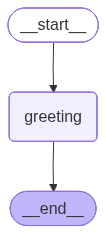

In [41]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [42]:
result = app.invoke({"message":"hello"})
result["message"]

'hello you are doing an amazing job learning langgraph'